# Evaluation of Model Optimization Statistics

This notebook loads and visualizes the results from the model performance simulations and statistical tests.

**Prerequisites:** Run `run_optimization_statistics.py` first to generate the results files.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

from popy.config import PROJECT_PATH_LOCAL, COLORS

def run_statistical_tests(model_performances):
    """Perform Mann-Whitney U tests for specific model pairs."""
    
    # Define specific comparisons to perform
    comparison_pairs = [
        ("Foraging", "Inferential RL - stickiness"),
        ("Foraging", "HSMMAgent"),
        ("Inferential RL - stickiness", "HSMMAgent"),
        ("Standard RL - stickiness", "Foraging"),
        ("Standard RL - stickiness", "Inferential RL - stickiness"),
        ("WSLS", "Foraging"),
        ("WSLS", "Inferential RL - stickiness"),
    ]
    
    # Perform pairwise Mann-Whitney U tests
    comparisons = []
    for model_a, model_b in comparison_pairs:
        perf_a = model_performances[model_performances['Model'] == model_a]['Reward_Rate'].values
        perf_b = model_performances[model_performances['Model'] == model_b]['Reward_Rate'].values
        
        # Mann-Whitney U test (two-sided)
        statistic, p_value = mannwhitneyu(perf_a, perf_b, alternative='two-sided')
        
        comparisons.append({
            'Comparison': f'{model_a} vs. {model_b}',
            'Model_A': model_a,
            'Model_B': model_b,
            'U': int(statistic),
            'p': p_value,
            'p***': p_value < 0.001,
            'mean_a': np.mean(perf_a),
            'mean_b': np.mean(perf_b),
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(comparisons)
    
    return results_df

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-t09h6gpe because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load Results

In [2]:
# Load performance data
perf_path = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'optimizing', 'statistics_performances.csv')
performance_df = pd.read_csv(perf_path)

print("N per model:")
print(performance_df['Model'].value_counts())

performance_df

N per model:
Model
WSLS                           100
Standard RL - stickiness       100
Inferential RL - stickiness    100
Foraging                       100
HSMMAgent                      100
Name: count, dtype: int64


,Model,Replication,Reward_Rate
0,WSLS,0,0.48350
1,WSLS,1,0.48271
2,WSLS,2,0.48629
3,WSLS,3,0.48450
4,WSLS,4,0.48486
...,...,...,...
495,HSMMAgent,95,0.63859
496,HSMMAgent,96,0.63615
497,HSMMAgent,97,0.63595
498,HSMMAgent,98,0.63825


In [3]:
# Load statistical comparison results
comparisons_df = run_statistical_tests(performance_df)

print(f"Loaded {len(performance_df)} performance records")
print(f"Computed {len(comparisons_df)} statistical comparisons")

comparisons_df

Loaded 500 performance records
Computed 7 statistical comparisons


,Comparison,Model_A,Model_B,U,p,p***,mean_a,mean_b
0,Foraging vs. Inferential RL - stickiness,Foraging,Inferential RL - stickiness,17,4.262995e-34,True,0.578442,0.585642
1,Foraging vs. HSMMAgent,Foraging,HSMMAgent,0,2.559835e-34,True,0.578442,0.637453
2,Inferential RL - stickiness vs. HSMMAgent,Inferential RL - stickiness,HSMMAgent,0,2.559547e-34,True,0.585642,0.637453
3,Standard RL - stickiness vs. Foraging,Standard RL - stickiness,Foraging,0,2.559980e-34,True,0.551558,0.578442
4,Standard RL - stickiness vs. Inferential RL - ...,Standard RL - stickiness,Inferential RL - stickiness,0,2.559691e-34,True,0.551558,0.585642
5,WSLS vs. Foraging,WSLS,Foraging,0,2.559115e-34,True,0.484465,0.578442
6,WSLS vs. Inferential RL - stickiness,WSLS,Inferential RL - stickiness,0,2.558826e-34,True,0.484465,0.585642


## Statistical Comparison Results

In [4]:
# Display comparison results with scientific notation for p-values
pd.options.display.float_format = '{:.2e}'.format

print("\nMann-Whitney U Test Results:")
print(comparisons_df[['Comparison', 'U', 'p', 'mean_a', 'mean_b']].to_string(index=False))

comparisons_df


Mann-Whitney U Test Results:
                                              Comparison  U        p   mean_a   mean_b
                Foraging vs. Inferential RL - stickiness 17 4.26e-34 5.78e-01 5.86e-01
                                  Foraging vs. HSMMAgent  0 2.56e-34 5.78e-01 6.37e-01
               Inferential RL - stickiness vs. HSMMAgent  0 2.56e-34 5.86e-01 6.37e-01
                   Standard RL - stickiness vs. Foraging  0 2.56e-34 5.52e-01 5.78e-01
Standard RL - stickiness vs. Inferential RL - stickiness  0 2.56e-34 5.52e-01 5.86e-01
                                       WSLS vs. Foraging  0 2.56e-34 4.84e-01 5.78e-01
                    WSLS vs. Inferential RL - stickiness  0 2.56e-34 4.84e-01 5.86e-01


,Comparison,Model_A,Model_B,U,p,p***,mean_a,mean_b
0,Foraging vs. Inferential RL - stickiness,Foraging,Inferential RL - stickiness,17,4.26e-34,True,5.78e-01,5.86e-01
1,Foraging vs. HSMMAgent,Foraging,HSMMAgent,0,2.56e-34,True,5.78e-01,6.37e-01
2,Inferential RL - stickiness vs. HSMMAgent,Inferential RL - stickiness,HSMMAgent,0,2.56e-34,True,5.86e-01,6.37e-01
3,Standard RL - stickiness vs. Foraging,Standard RL - stickiness,Foraging,0,2.56e-34,True,5.52e-01,5.78e-01
4,Standard RL - stickiness vs. Inferential RL - ...,Standard RL - stickiness,Inferential RL - stickiness,0,2.56e-34,True,5.52e-01,5.86e-01
5,WSLS vs. Foraging,WSLS,Foraging,0,2.56e-34,True,4.84e-01,5.78e-01
6,WSLS vs. Inferential RL - stickiness,WSLS,Inferential RL - stickiness,0,2.56e-34,True,4.84e-01,5.86e-01


## Visualizations

### Distribution of Reward Rates

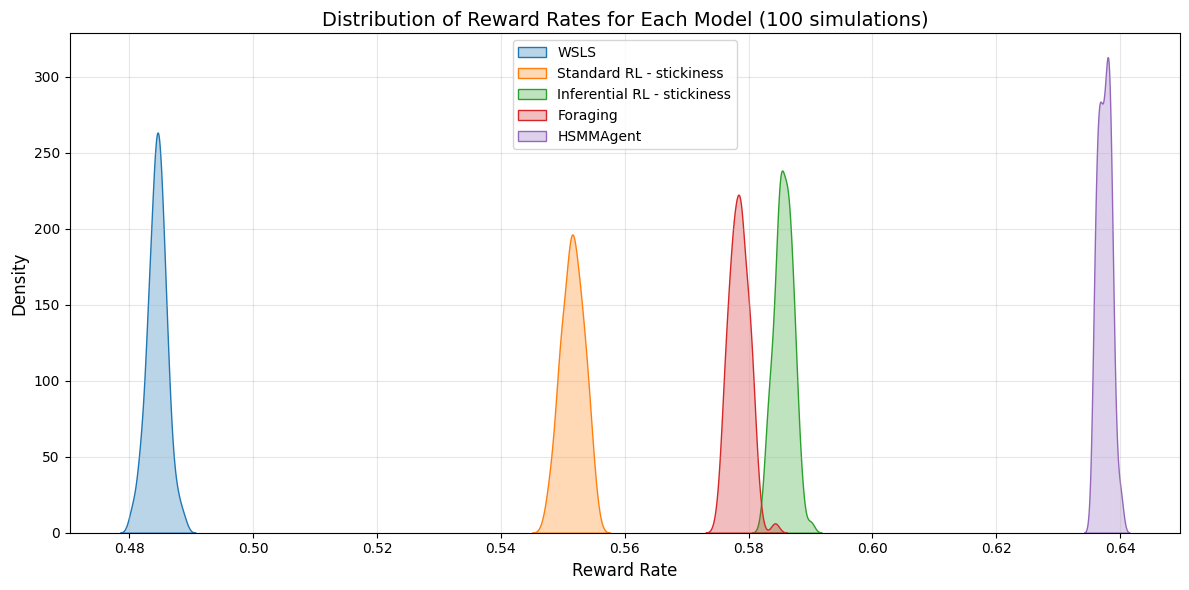

In [5]:
plt.figure(figsize=(12, 6))

# Get unique models
models = performance_df['Model'].unique()

for model in models:
    rewards = performance_df[performance_df['Model'] == model]['Reward_Rate']
    sns.kdeplot(rewards, label=model, fill=True, alpha=0.3)

plt.xlabel('Reward Rate', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Reward Rates for Each Model (100 simulations)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Box Plot Comparison

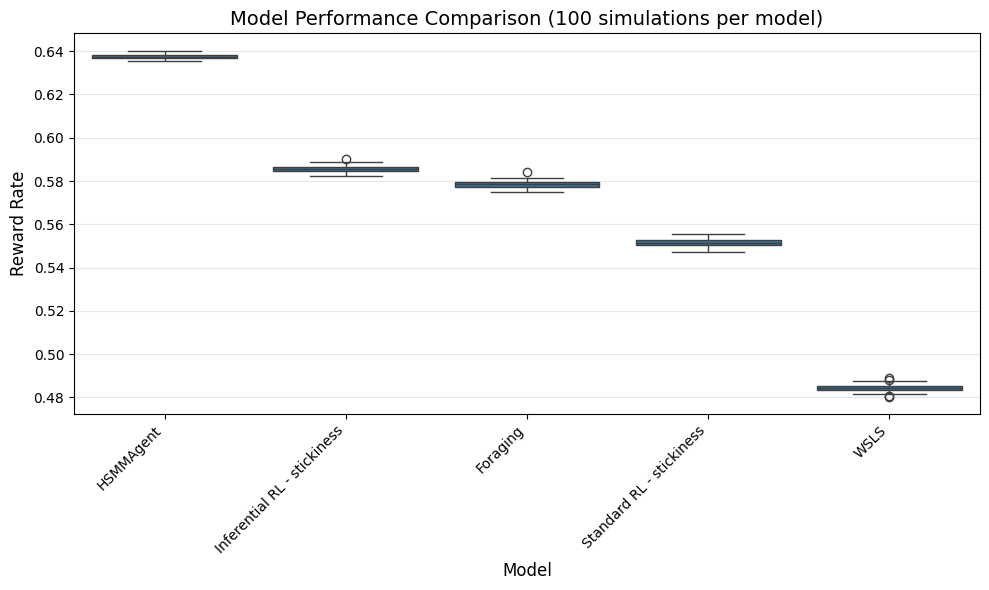

In [6]:
plt.figure(figsize=(10, 6))

# Sort models by median performance
model_order = performance_df.groupby('Model')['Reward_Rate'].median().sort_values(ascending=False).index

sns.boxplot(data=performance_df, x='Model', y='Reward_Rate', order=model_order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Reward Rate', fontsize=12)
plt.title('Model Performance Comparison (100 simulations per model)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Violin Plot

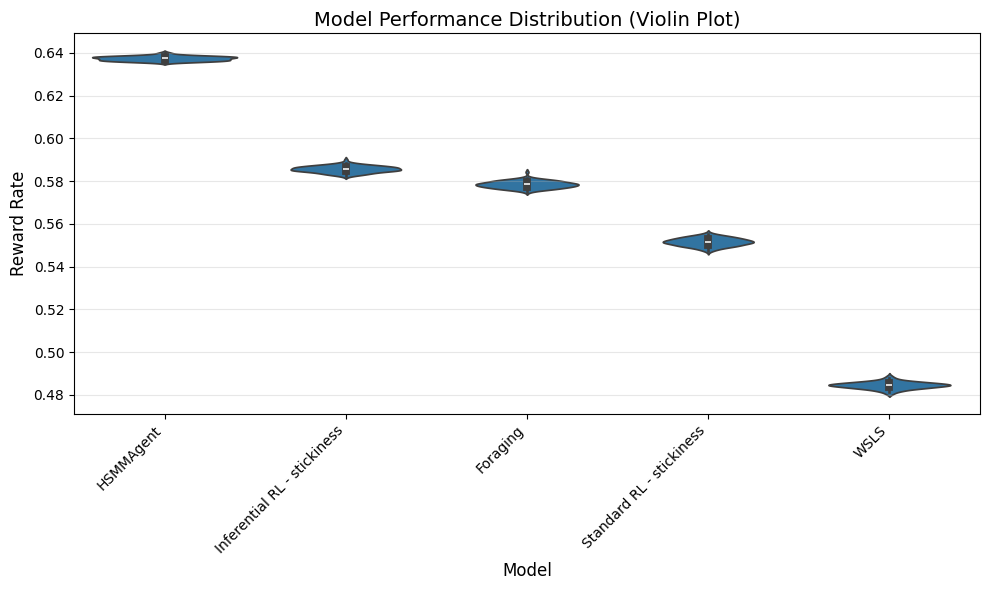

In [7]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=performance_df, x='Model', y='Reward_Rate', order=model_order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Reward Rate', fontsize=12)
plt.title('Model Performance Distribution (Violin Plot)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### P-value Heatmap